In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel('/content/ABC Company.xlsx')

In [6]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


In [8]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [9]:
#Preprocessing

df['Height'] = np.random.randint(150, 181, size=len(df))
df['Height']

,Height
0,152
1,165
2,176
3,155
4,167
...,...
453,173
454,163
455,150
456,156


In [10]:
df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,84
Salary,11


In [11]:
#handling missing values

df['Salary']=df['Salary'].fillna(df['Salary'].median())
df['College'] = df['College'].fillna('No College')

In [12]:
df.isnull().sum()

,0
Name,0
Team,0
Number,0
Position,0
Age,0
Height,0
Weight,0
College,0
Salary,0


# Analysis Tasks

# 1. Determine the distribution of employees across each team and calculate the percentage split relative to the total number of employees.

In [13]:
df_distribution = df['Team'].value_counts()
df_distribution

,count
Team,
New Orleans Pelicans,19
Memphis Grizzlies,18
Utah Jazz,16
Milwaukee Bucks,16
New York Knicks,16
Boston Celtics,15
Los Angeles Clippers,15
Los Angeles Lakers,15
Phoenix Suns,15


In [14]:
df_percentage=((df_distribution/len(df))*100).round(2)
df_percentage

,count
Team,
New Orleans Pelicans,4.15
Memphis Grizzlies,3.93
Utah Jazz,3.49
Milwaukee Bucks,3.49
New York Knicks,3.49
Boston Celtics,3.28
Los Angeles Clippers,3.28
Los Angeles Lakers,3.28
Phoenix Suns,3.28


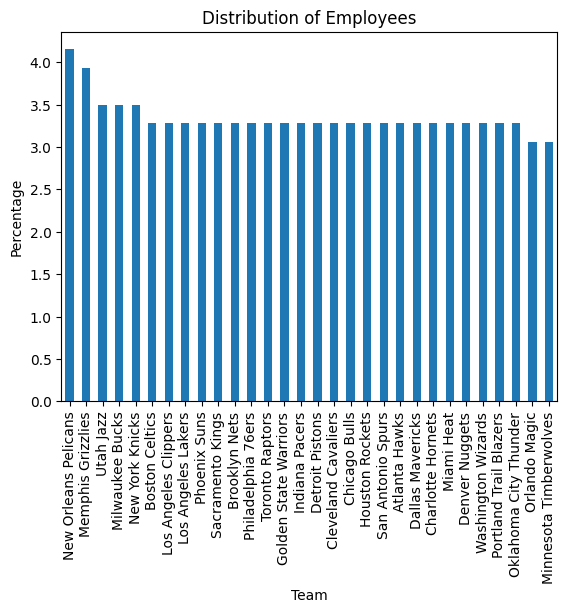

In [15]:
#visualization

df_percentage.plot(kind='bar')
plt.xlabel('Team')
plt.ylabel('Percentage')
plt.title('Distribution of Employees')
plt.show()

# 2. Segregate employees based on their positions within the company.

In [16]:
df_position = df['Position'].value_counts()
df_position

,count
Position,
SG,102
PF,100
PG,92
SF,85
C,79


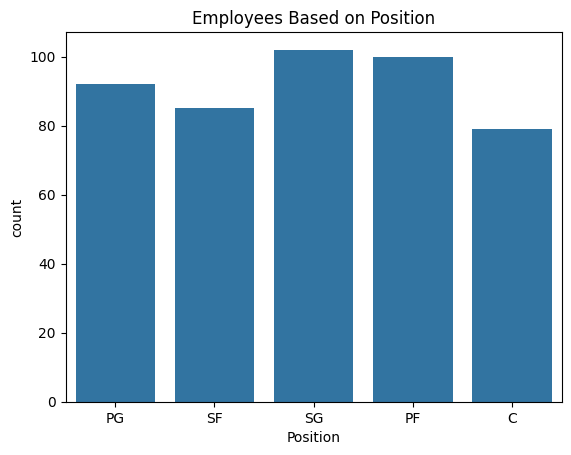

In [17]:
#visualization

sns.countplot(data=df,x='Position')
plt.xlabel('Position')
plt.title('Employees Based on Position')
plt.show()

# 3. Identify the predominant age group among employees.

In [18]:
df['Age'].min()

19

In [19]:
df['Age'].max()

40

In [20]:
bins=[19,25,30,35,40]
labels=['19-25','26-30','31-35','36-40']
df['Age Group']=pd.cut(df['Age'],bins=bins,labels=labels)
df_grouped = df['Age Group'].value_counts()
df_grouped

,count
Age Group,
19-25,198
26-30,167
31-35,68
36-40,23


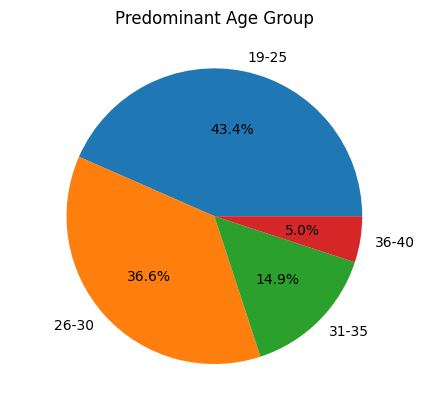

In [21]:
#visualization

df_grouped.plot(kind='pie',autopct='%1.1f%%')
plt.title('Predominant Age Group')

plt.ylabel(' ')
plt.show()


# 4. Discover which team and position have the highest salary expenditure.

In [22]:
df_team_sal=df.groupby('Team')['Salary'].sum()
df_team_sal

,Salary
Team,
Atlanta Hawks,72902950.0
Boston Celtics,61377254.0
Brooklyn Nets,52528475.0
Charlotte Hornets,78340920.0
Chicago Bulls,86783378.0
Cleveland Cavaliers,109824875.0
Dallas Mavericks,71198732.0
Denver Nuggets,62958116.0
Detroit Pistons,67168263.0


In [23]:
df_team_sal.idxmax()

'Cleveland Cavaliers'

In [24]:
df_pos_sal=df.groupby('Position')['Salary'].sum()
df_pos_sal

,Salary
Position,
C,466377332.0
PF,451069408.0
PG,458193715.0
SF,410857162.0
SG,405484816.0


In [25]:
df_pos_sal.idxmax()

'C'

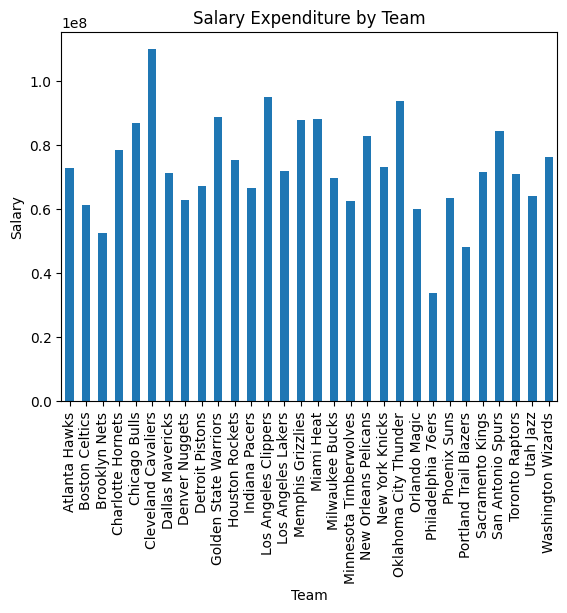

In [26]:
#visualization

df_team_sal.plot(kind='bar',xlabel='Team',ylabel='Salary')
plt.title('Salary Expenditure by Team')
plt.show()

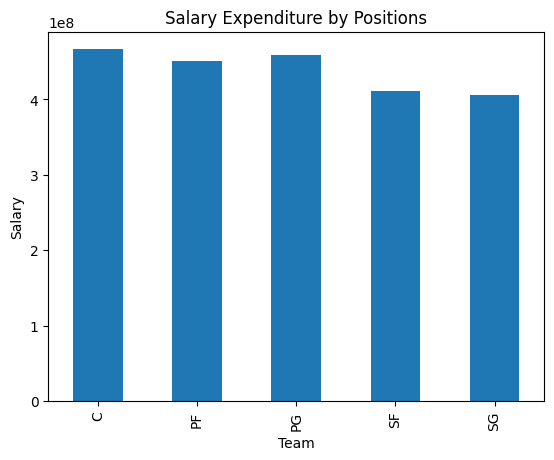

In [27]:
df_pos_sal.plot(kind='bar',xlabel='Team',ylabel='Salary')
plt.title('Salary Expenditure by Positions')
plt.show()

# 5. Investigate if there's any correlation between age and salary, and represent it visually.

In [29]:
df_correlation = df['Age'].corr(df['Salary'])
print(df_correlation)

0.2091241911519606


Text(0.5, 1.0, 'Correlation between Age vs Salary')

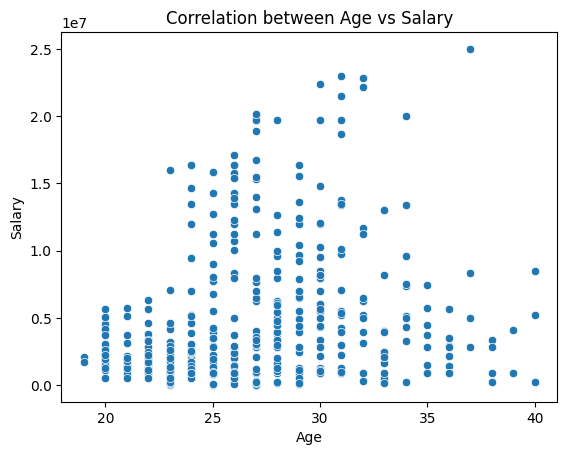

In [30]:
#visualization

sns.scatterplot(data=df,x='Age',y='Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Correlation between Age vs Salary')

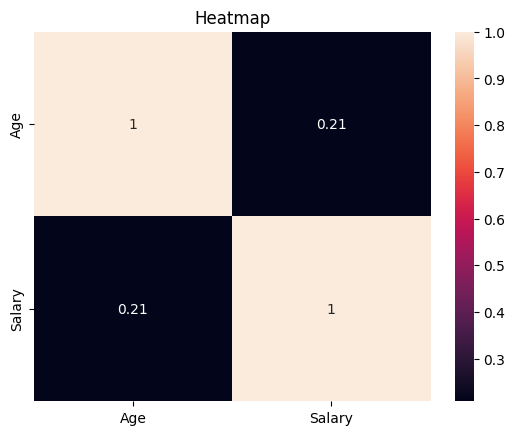

In [35]:
sns.heatmap(df[['Age', 'Salary']].corr(), annot=True)
plt.title('Heatmap')
plt.show()

# Data Story



*  New Orleans Pelicans has the highest number of employees. Employee distribution across teams is fairly balanced.
*   Most employees belong to positions like SG and PF, while fewer employees are in the Center position.
*   The company mainly consists of younger employees.
*   Cleveland Cavaliers spend the highest total salary. Center position has the highest salary expenditure.
*   The correlation analysis between age and salary shows a weak positive relationship (0.21).





